# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [263]:
#One Marketing campaign - to sell long term deposits to people either calling in with complaints (inbound) or agents making calls to list of client (outbound)c

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [471]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,RobustScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder,PowerTransformer, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
import time
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay



In [265]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [266]:
df.head()
df.tail(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41178,62,retired,married,university.degree,no,no,no,cellular,nov,thu,...,2,6,3,success,-1.1,94.767,-50.8,1.031,4963.6,yes
41179,64,retired,divorced,professional.course,no,yes,no,cellular,nov,fri,...,3,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41180,36,admin.,married,university.degree,no,no,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41181,37,admin.,married,university.degree,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41182,29,unemployed,single,basic.4y,no,yes,no,cellular,nov,fri,...,1,9,1,success,-1.1,94.767,-50.8,1.028,4963.6,no
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [268]:
# stats for numerical columns
df.describe()

# Finding -
# age - 17-98 year olds contacted. IQR is betweeb 47-32 years .Will have to check for outliers.
# duration - can be ignored per data guidelines
# Campaign - mean is 2.56, max is 56 times contacted indicating outlier
# pdays - 999 means not previously contacted, data needs to be cleaned, as higher number can give incoorrect results
# previous - data seems sparse, will have to take closer look
# emp.var.rate - reflects whether job market is growing. + -> more jobs, - -> job losses
# cons.price.idx - A monthly indicator that measures the average change in prices paid by consumers for goods and services - 
# A higher CPI = prices are rising = purchasing power is falling
#euribor3m - A higher Euribor = higher lending rates across the economy = term deposits become more attractive to customers
#nr.employed -quarterly indicator of the number of employees in the economy
#cons.conf.idx - how optimistic or pessimistic consumers feel about the economy and their finances
# A less negative (higher) value = consumers are more confident about the economy
# A more negative (lower) value = consumers are pessimistic, worried about job security or finances

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [269]:
df.isnull().sum() 
# As stated in the data description there are no null values but 'unknown' values in categorical columns

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [270]:
#Univariate Analysis

In [271]:
#Checking target column
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

<Axes: ylabel='count'>

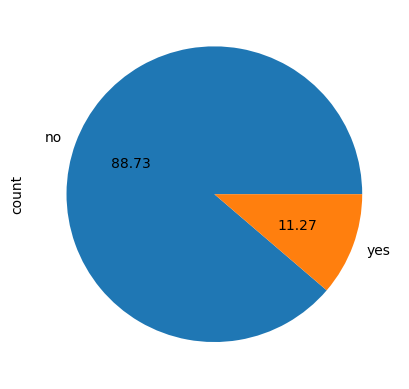

In [272]:
df['y'].value_counts().plot(kind='pie', autopct='%.2f')

#Finding - Data is highly imbalanced with more people opting out of the campaign than those enrolling

In [273]:
#drop duration per recommendation
df = df.drop('duration',axis = 1)


In [274]:
#get all numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()
len(num_cols)

9

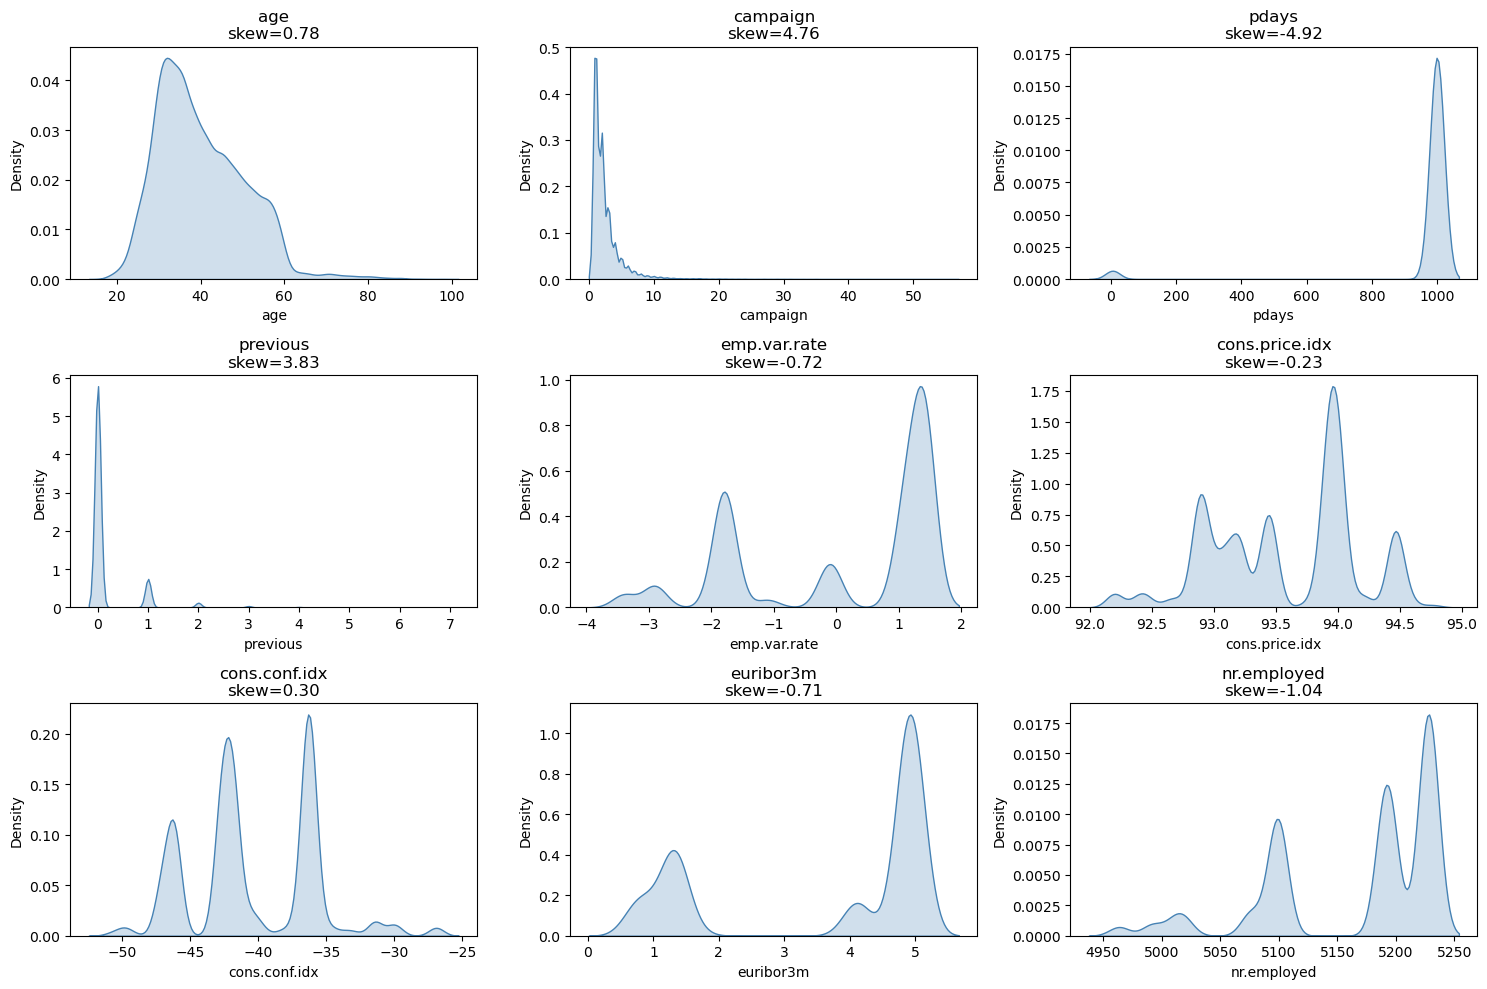

In [275]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(df[col], ax=axes[i], fill=True, color='steelblue')
    axes[i].set_title(f'{col}\nskew={df[col].skew():.2f}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#Finding - campaign,pdays, previous have outliers that need to be cleaned
# the economy columns have variable data that may need normalization
# Skew > 1 or < -1 - columns need transformation. campaign,pdays, previous, emp.var.rate, euribor3m can benefit from transformation

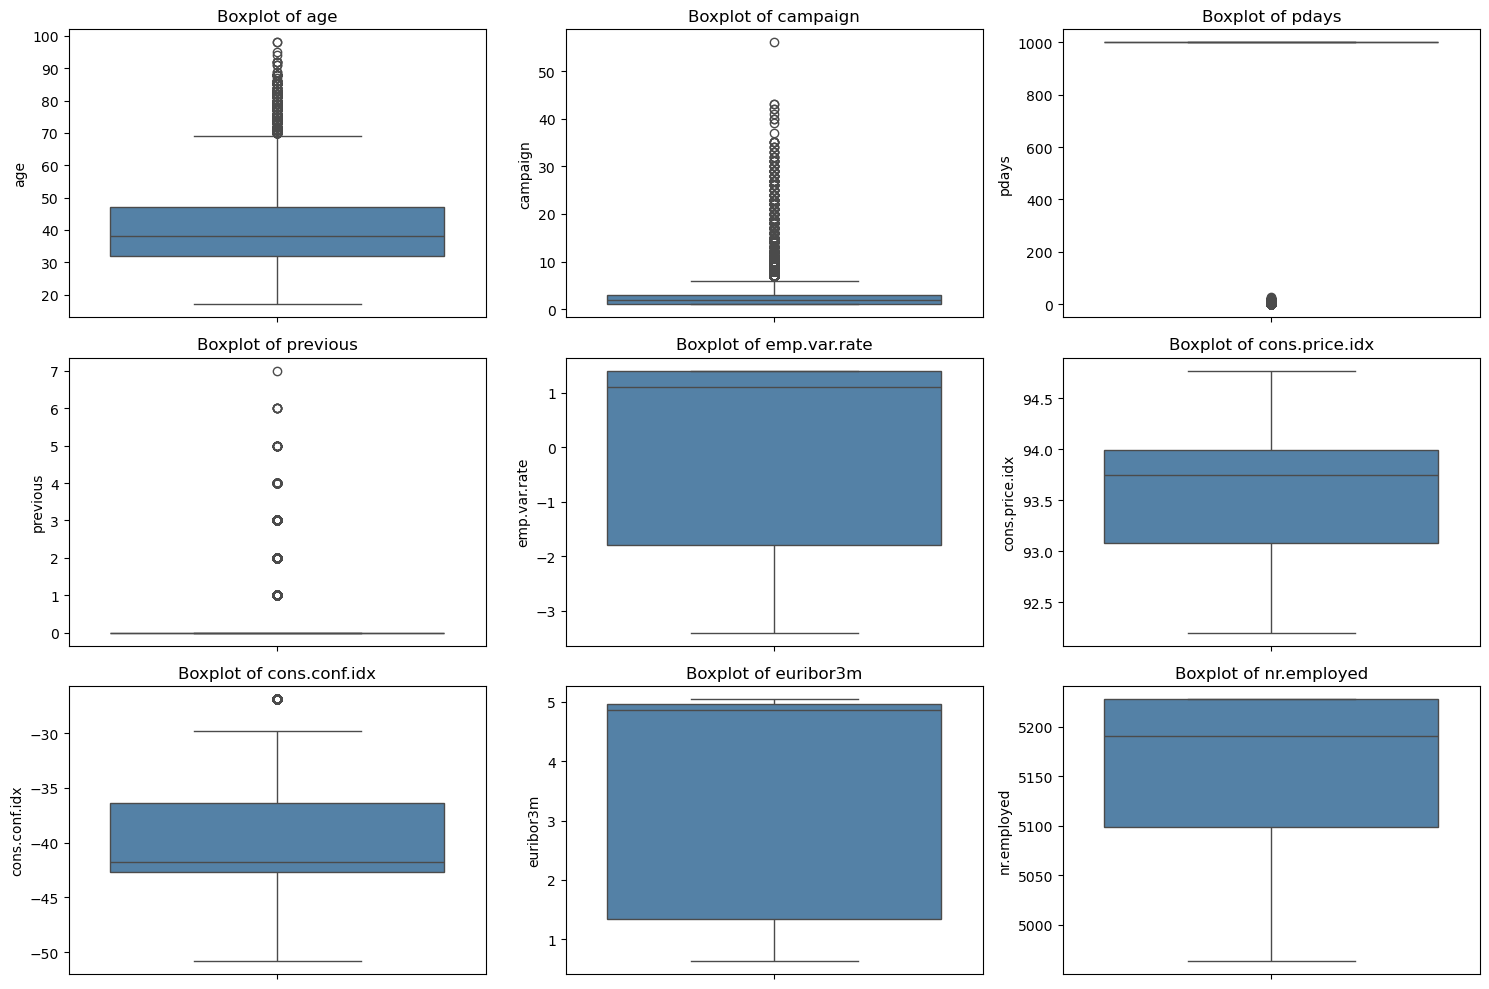

In [209]:
#Box plot to better visualize outliers

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

#Finding - Age,campaign,pdays,previous have a lot of outliers
#Age has a lot of outliers
#looks like for pdays most values are 999 - which is they werent contacted before - same with previous column, these 2 could be correlated


In [210]:
filtered_df = df[df['age'] > 85]
result = filtered_df.groupby('y')['age'].value_counts().unstack(fill_value=0)
result

#Finding - 21 people over 85 have enrolled in the campaign

age,86,87,88,89,91,92,94,95,98
y,,,,,,,,,
no,3,0,13,0,2,1,1,1,0
yes,5,1,9,2,0,3,0,0,2


In [211]:
filtered_df = df[df['campaign'] > 20]
result = filtered_df.groupby('y')['campaign'].value_counts().unstack(fill_value=0)
result

campaign,21,22,23,24,25,26,27,28,29,30,...,33,34,35,37,39,40,41,42,43,56
y,,,,,,,,,,,,,,,,,,,,,
no,24,17,15,15,8,8,11,8,10,7,...,4,3,5,1,1,2,1,2,2,1
yes,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [212]:
for i in ['previous','age','campaign','pdays']:
    print(df[i].value_counts())

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64
age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
89       2
91       2
94       1
87       1
95       1
Name: count, Length: 78, dtype: int64
campaign
1     17642
2     10570
3      5341
4      2651
5      1599
6       979
7       629
8       400
9       283
10      225
11      177
12      125
13       92
14       69
17       58
16       51
15       51
18       33
20       30
19       26
21       24
22       17
23       16
24       15
27       11
29       10
28        8
26        8
25        8
31        7
30        7
35        5
32        4
33        4
34        3
42        2
40        2
43        2
56        1
39        1
41        1
37        1
Name: count, dtype: int64
pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26


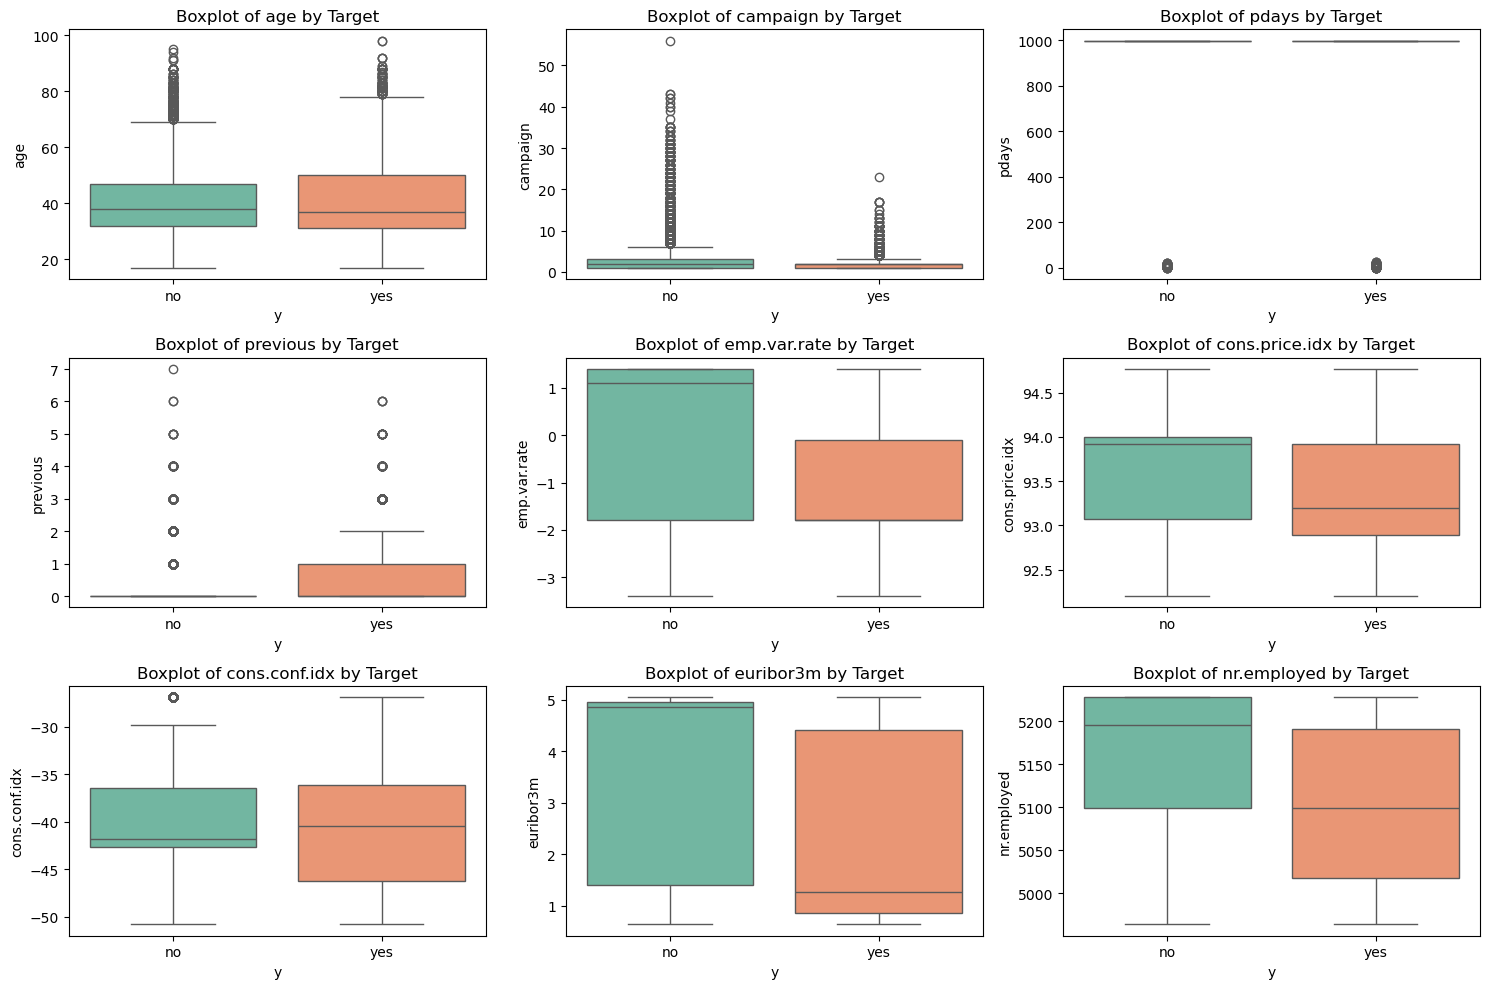

In [213]:
#Bivariate for numerical columns with target column 

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='y', y=col, ax=axes[i], palette='Set2', hue='y')
    axes[i].set_title(f'Boxplot of {col} by Target')

plt.tight_layout()
plt.show()

#Finding - Interesting insight - for economic indictors -for higher values (>75 - 90 %) emp.var.rate,eurobor3m,nr.employed, 
# customers are not taking up marketing offer

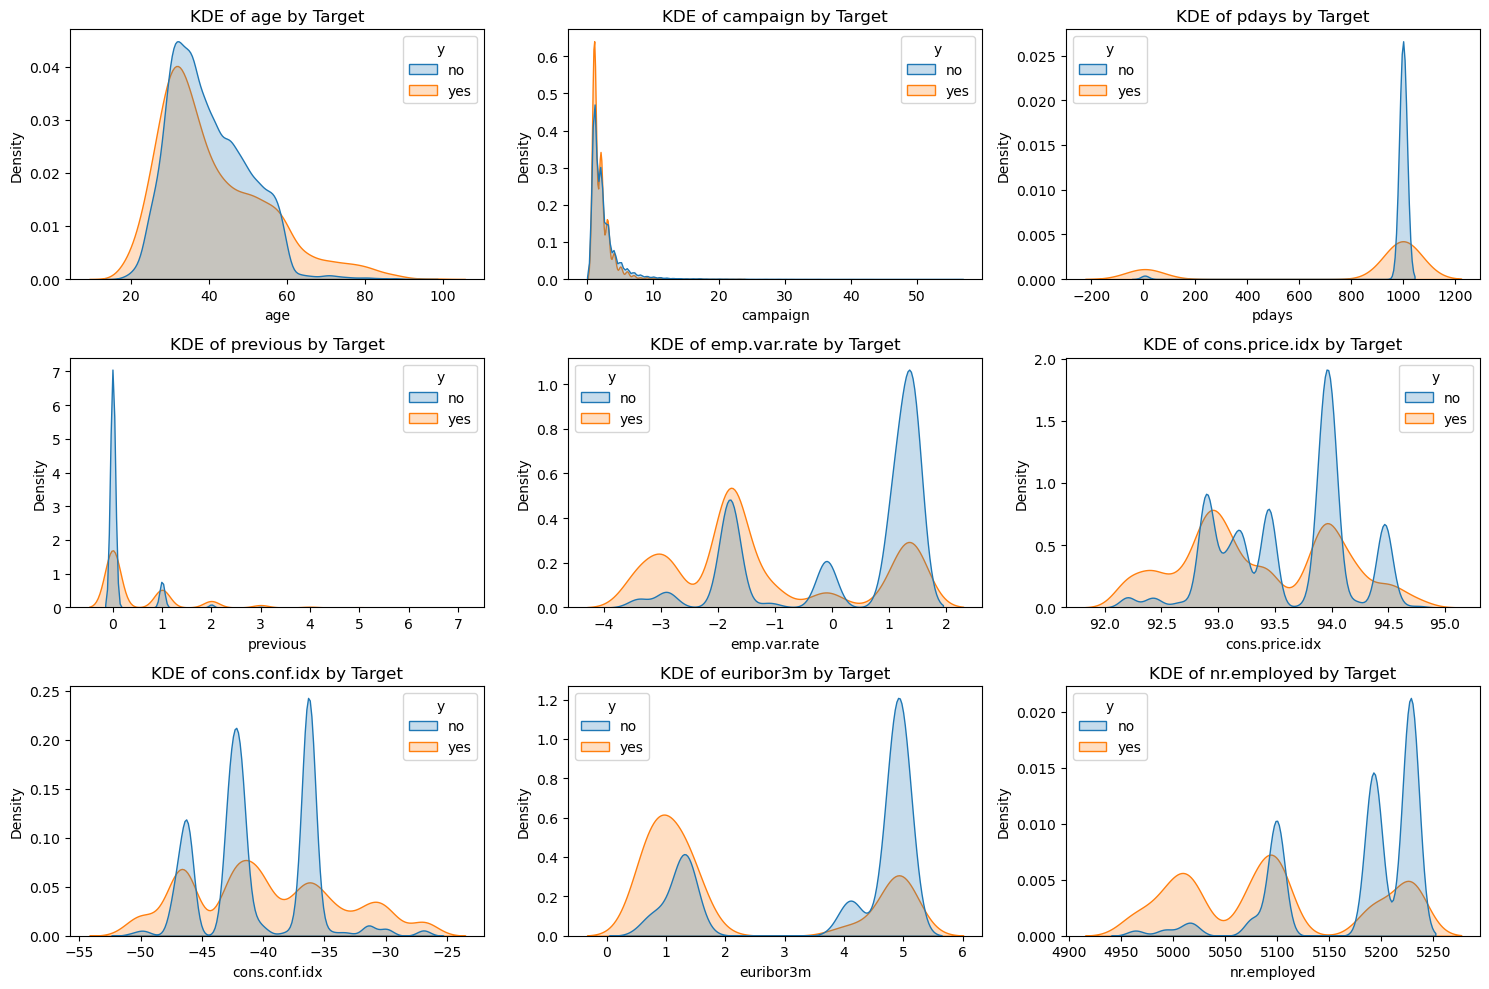

In [214]:

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='y', ax=axes[i], fill=True, common_norm=False)
    axes[i].set_title(f'KDE of {col} by Target')

plt.tight_layout()
plt.show()


In [215]:
#Analysing categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
len(cat_cols)

11

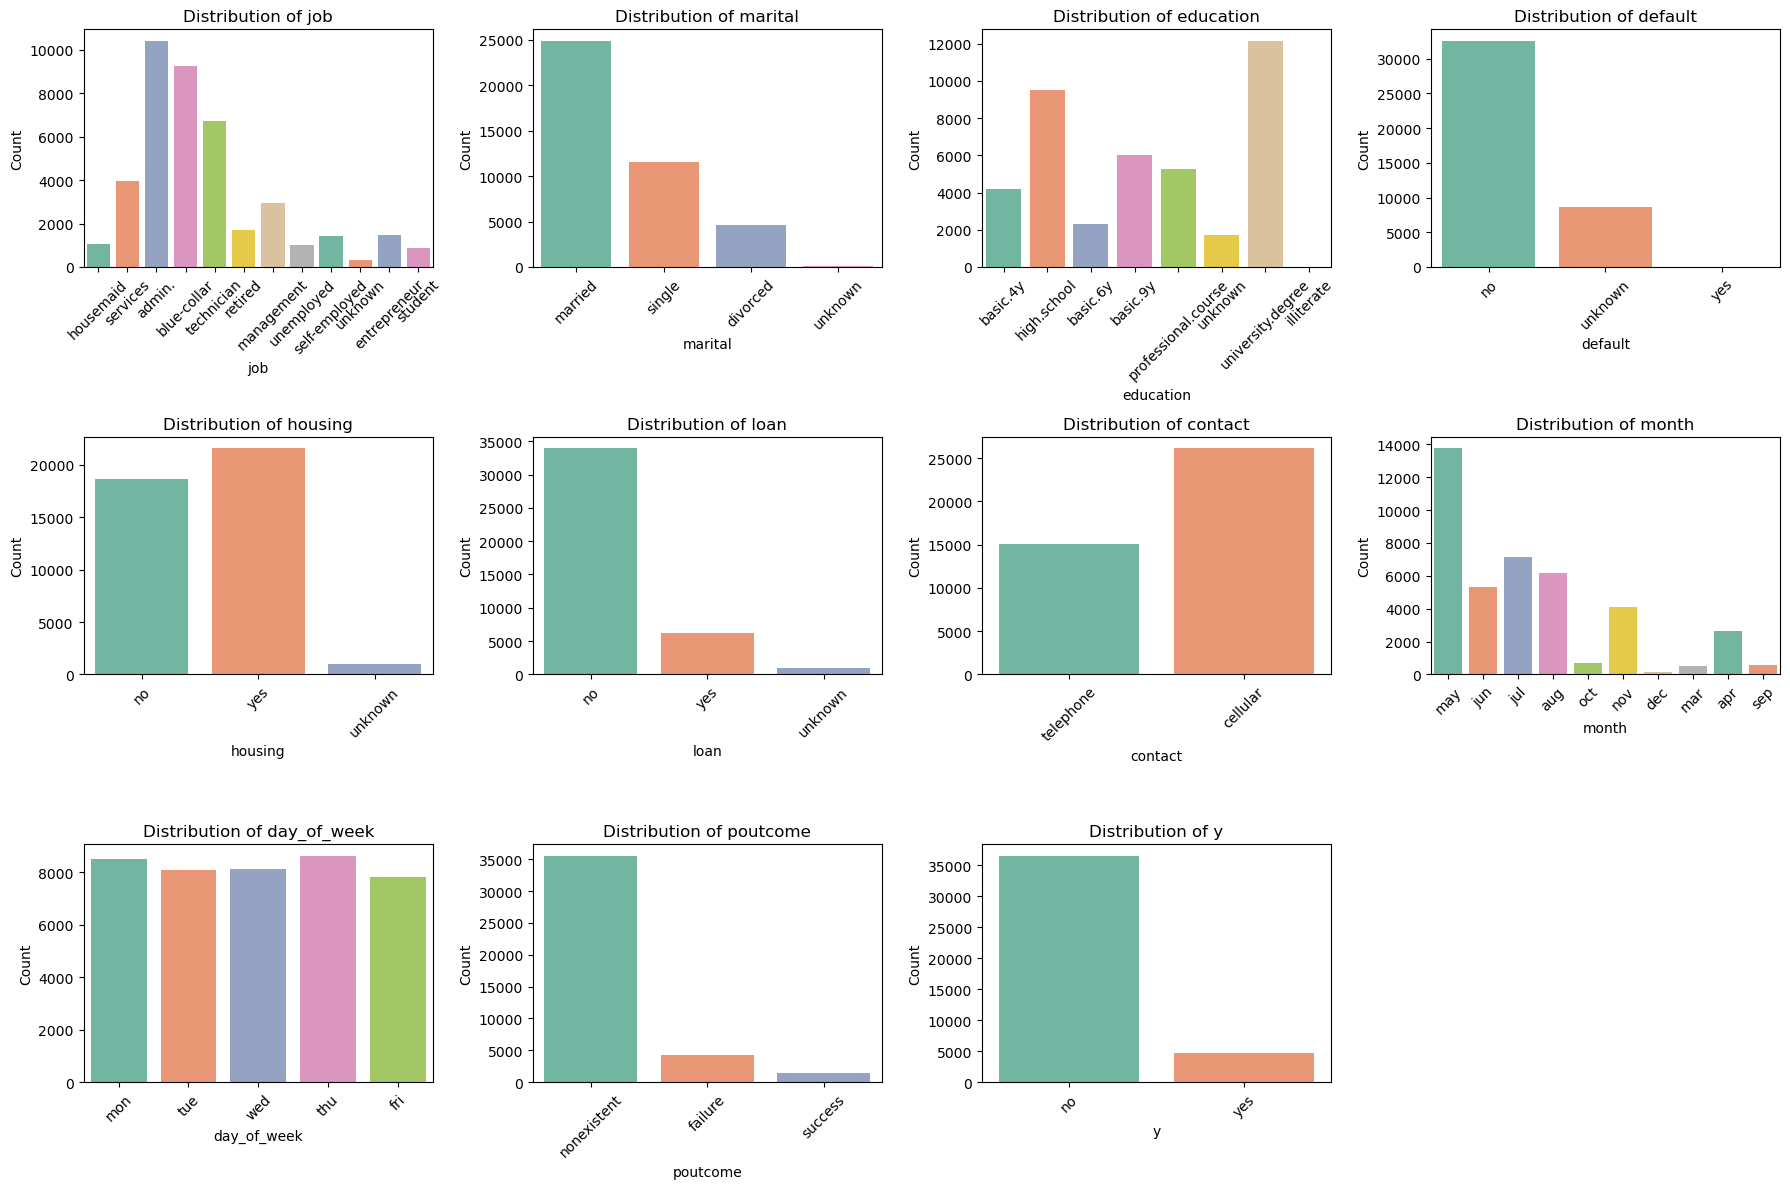

In [216]:
# Univariate for cat columns

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#Finding - 

In [157]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

/var/folders/c2/kgzx1gtn69zbvq_n_sj08vkm0000gn/T/ipykernel_21774/4016337429.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title='Subscribed', loc='upper right')


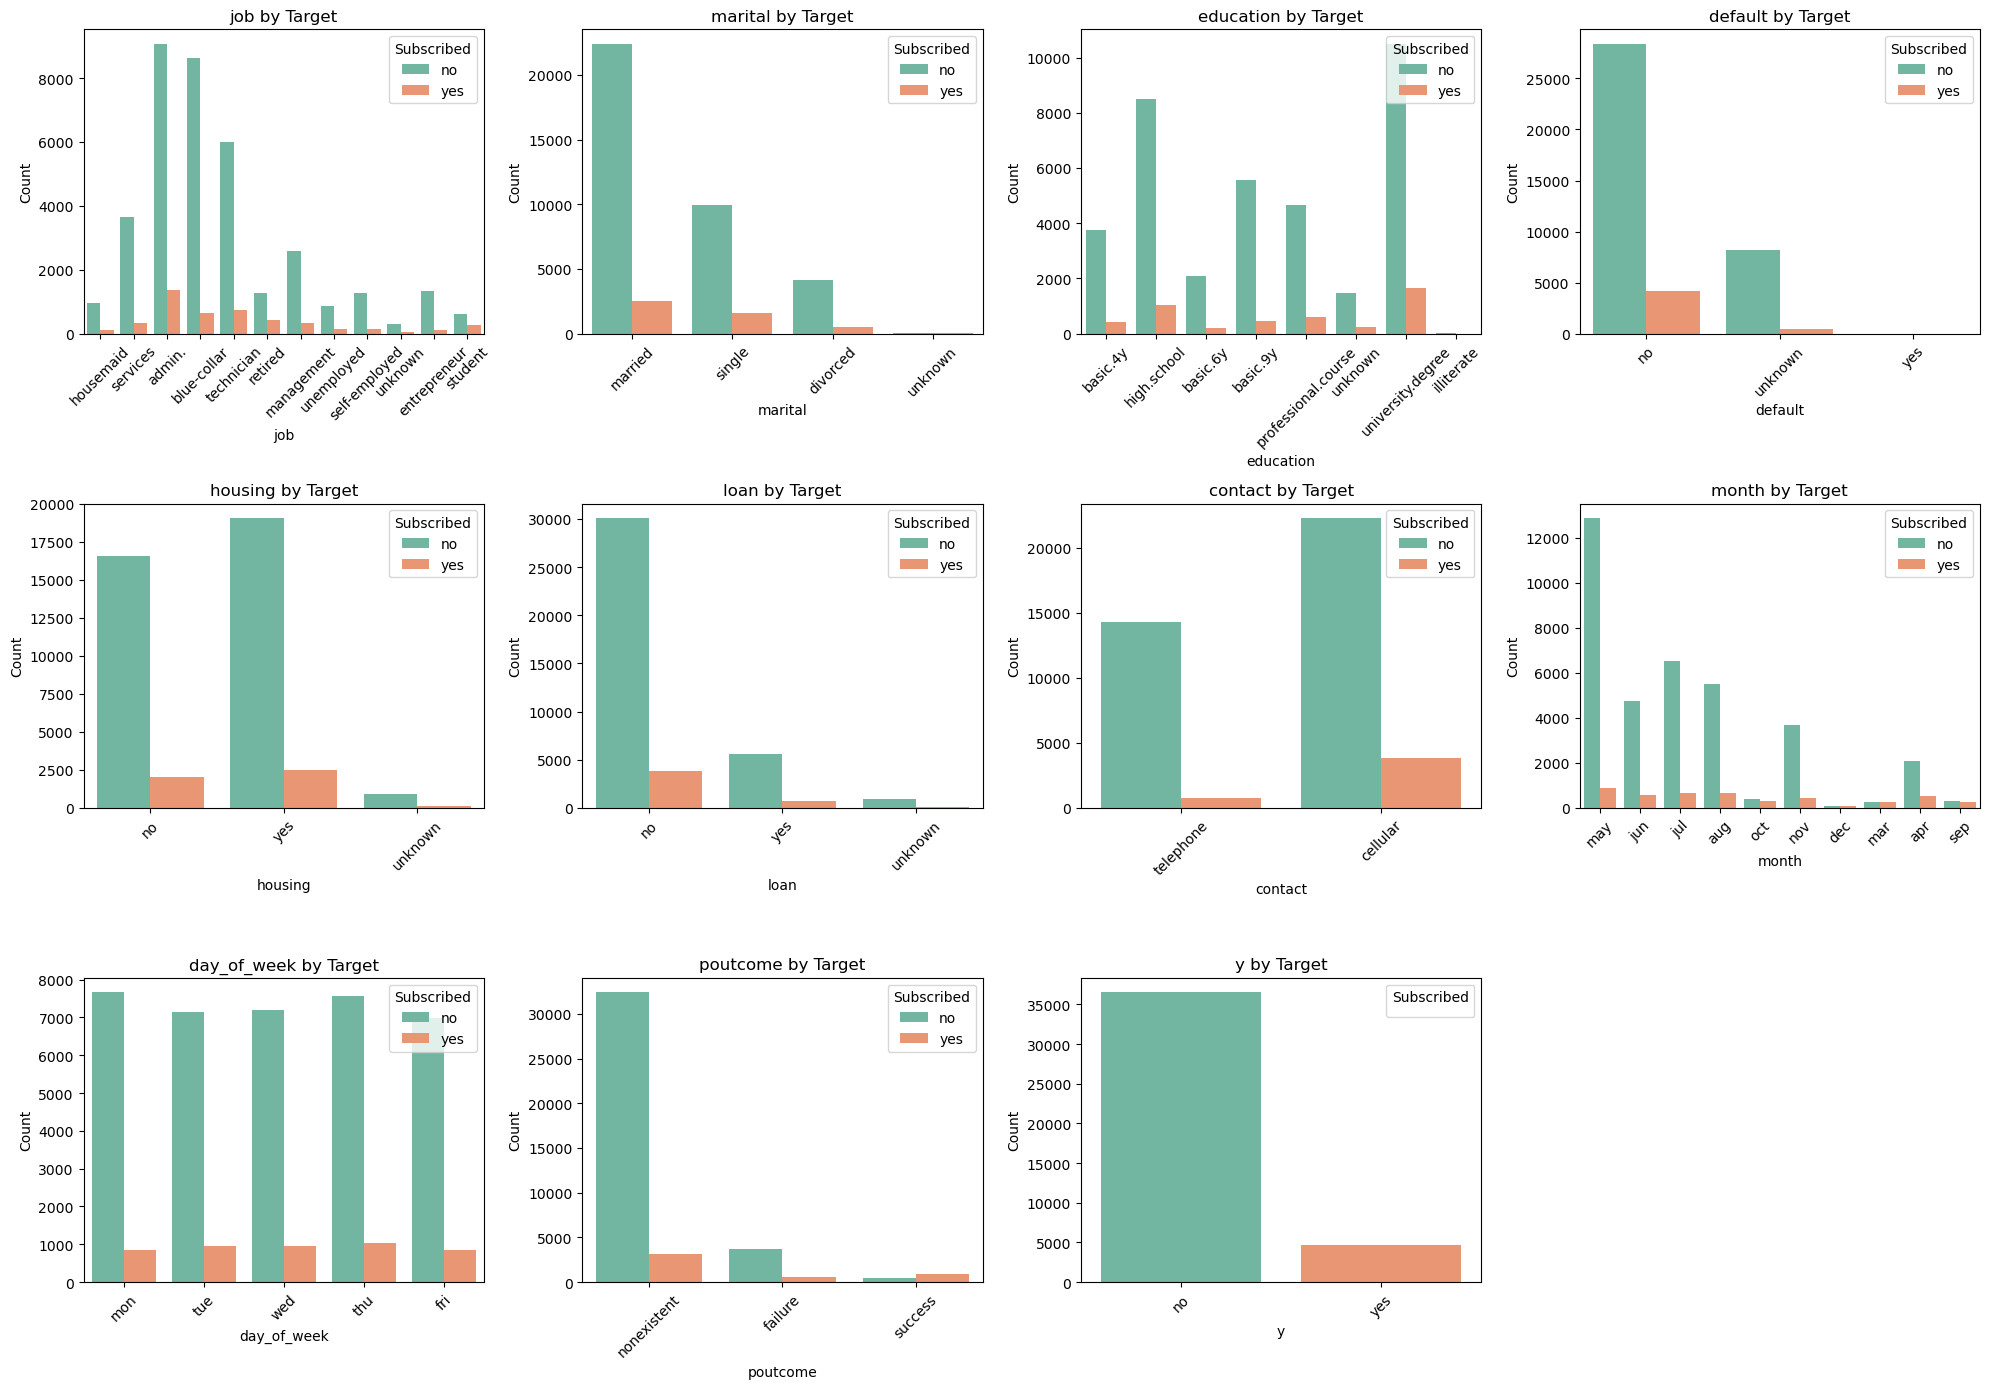

In [158]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='y', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Subscribed', loc='upper right')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#Finding - Significant markers -
#Admin., blue-collar, technicians had higher chances of saying yes
# Clients with no default, married, with degrees and using cellular had higher chances of signing up

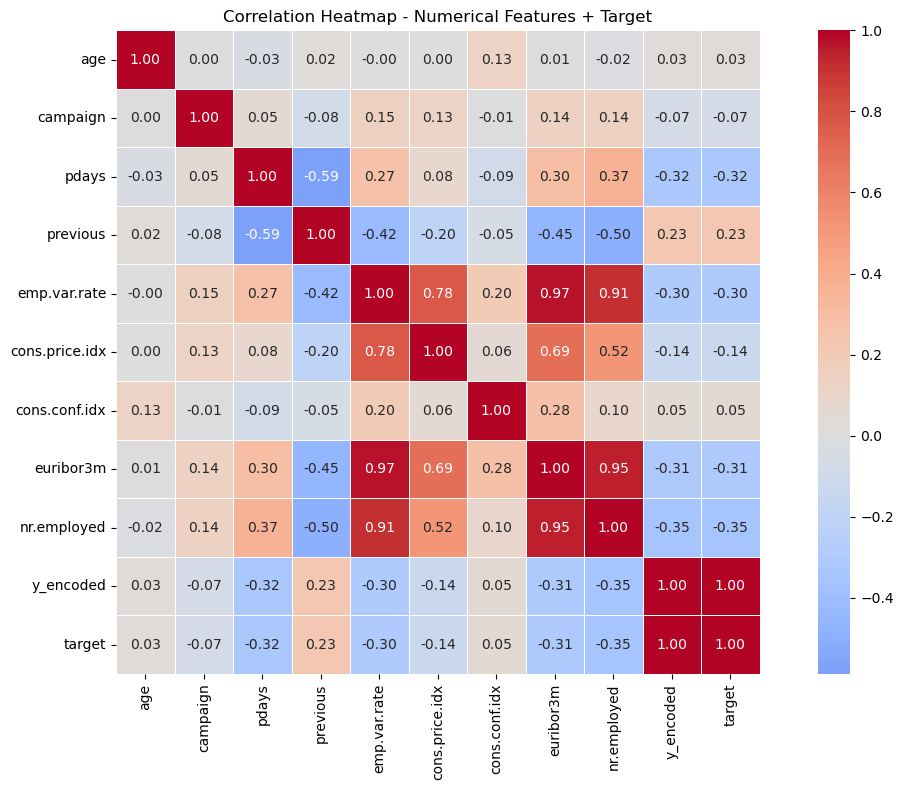

In [218]:
# correlation between features 
df['y_encoded'] = df['y'].map({'yes': 1, 'no': 0})
# Include encoded target in correlation
numerical_df = df.select_dtypes(include='number').copy()
numerical_df['target'] = df['y_encoded']

corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap - Numerical Features + Target')
plt.tight_layout()
plt.show()

#Finding - high correlation exists between 
#euribor3m - emp.var.rate 
# euribor3m - 

In [219]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_encoded
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,1
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,1


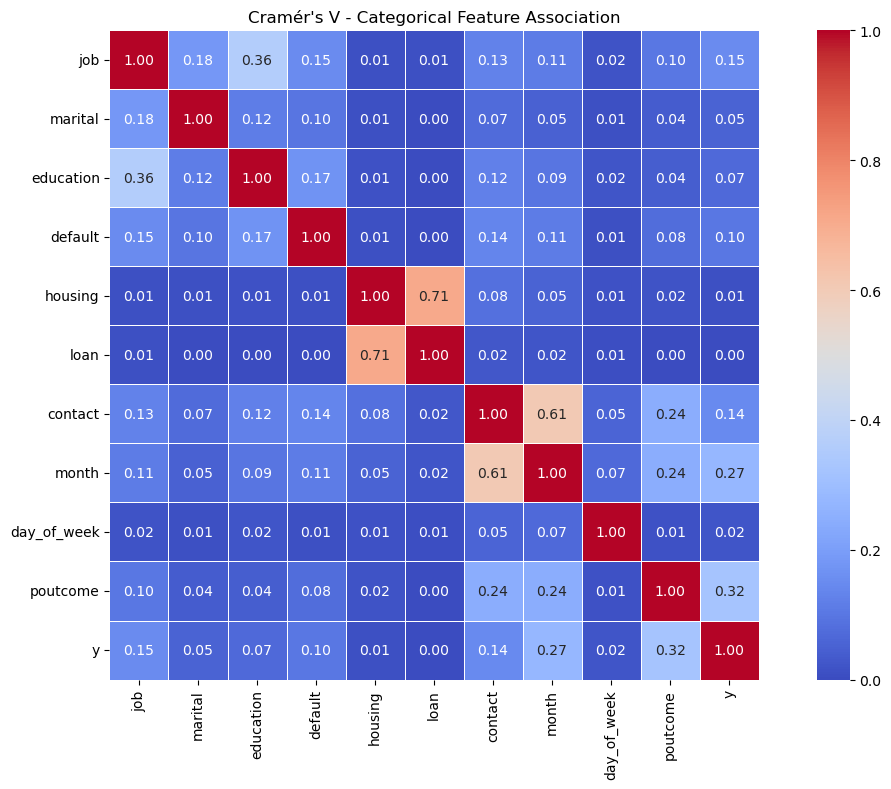

In [109]:

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Build Cramér's V matrix
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cramers_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0.5, linewidths=0.5, square=True)
plt.title("Cramér's V - Categorical Feature Association")
plt.tight_layout()
plt.show()


#Finding - for Target variable - job,poutcome,contact and month have significant impact
#loan has no impact, whereas housing,day of week have minimal impact


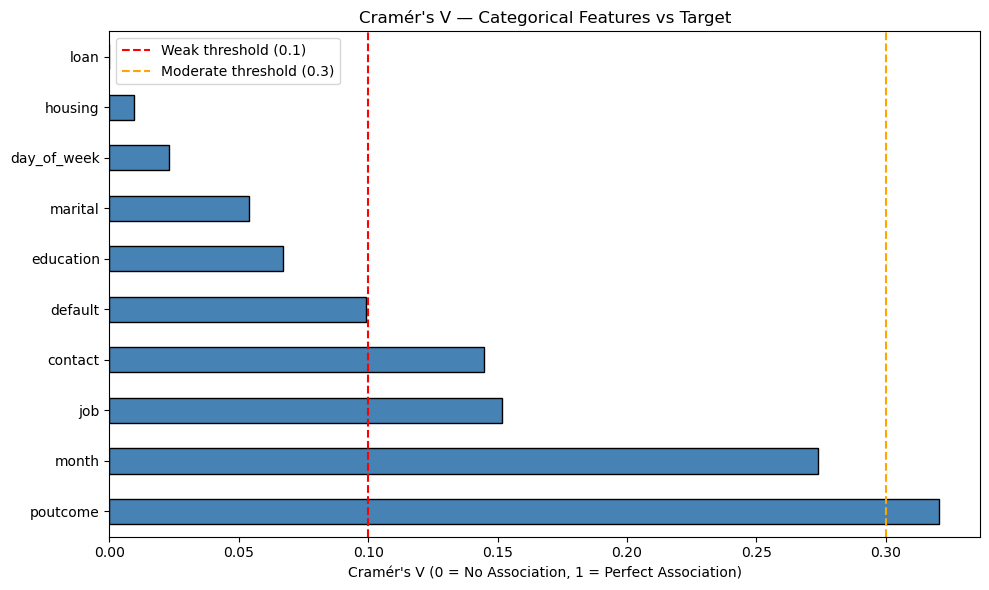

In [113]:
cramers_scores = {}
for col in cat_cols:
    if col != 'y':
        cramers_scores[col] = cramers_v(df[col], df['y'])

cramers_series = pd.Series(cramers_scores).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
cramers_series.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Cramér's V — Categorical Features vs Target")
plt.xlabel("Cramér's V (0 = No Association, 1 = Perfect Association)")
plt.axvline(x=0.1, color='red', linestyle='--', label='Weak threshold (0.1)')
plt.axvline(x=0.3, color='orange', linestyle='--', label='Moderate threshold (0.3)')
plt.legend()
plt.tight_layout()
plt.show()

#Finding - as evident from Cramer's V test, contact, job,month and poutcome have stronger relation to our target variable

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Business Objective 
 Identify the most likely customers to subscribe to a term deposit,
so the bank can focus its marketing efforts and reduce wasted calls. Bank can make targetted calls,
making sure interested customers are not missed and those not interested are not getting unnecessary calls.

In this usecase recall is more important than precision -
(Recall) - False negative - missed subscriber - making sure interested customers are not missed.
(Precision) - False positive - wrong prediction - uninterested customer is called, this is low business cost

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [220]:
# dropping euribor3m to prevent multicollinearity
df = df.drop(['euribor3m','day_of_week'], axis=1)

In [221]:
#update pdays -> set value for client never contacted to -1 from 999

# Flag: was the client previously contacted?
df['previously_contacted'] = (df['pdays'] != 999).astype(int)

# Replace 999 with -1 or NaN in original column
df['pdays'] = df['pdays'].replace(999, -1)

In [223]:
df

,age,job,marital,education,default,housing,loan,contact,month,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,nr.employed,y,y_encoded,previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,1,-1,0,nonexistent,1.1,93.994,-36.4,5191.0,no,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,1,-1,0,nonexistent,1.1,93.994,-36.4,5191.0,no,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,1,-1,0,nonexistent,1.1,93.994,-36.4,5191.0,no,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,1,-1,0,nonexistent,1.1,93.994,-36.4,5191.0,no,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,1,-1,0,nonexistent,1.1,93.994,-36.4,5191.0,no,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,1,-1,0,nonexistent,-1.1,94.767,-50.8,4963.6,yes,1,0
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,1,-1,0,nonexistent,-1.1,94.767,-50.8,4963.6,no,0,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,2,-1,0,nonexistent,-1.1,94.767,-50.8,4963.6,no,0,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,1,-1,0,nonexistent,-1.1,94.767,-50.8,4963.6,yes,1,0


In [224]:
#Initially, we will use only standard scaler and one-hot and ordinal encoder to transform the features

#Define final list of columns
ordinal_col    = ['education']
nominal_cols   = ['job', 'marital', 'default', 'housing', 'loan',
                  'contact', 'month', 'poutcome']
numerical_cols = ['age', 'campaign', 'pdays',
                  'previous', 'emp.var.rate', 'cons.price.idx',
                  'cons.conf.idx', 'nr.employed','previously_contacted']

# Replacing 'unknown' with nan so that it can be imputed in the pipeline later
df['education'] = df['education'].replace('unknown', np.nan)

#define order in education for ordinal encoding
education_order = [
    'illiterate',
    'basic.4y',
    'basic.6y',
    'basic.9y',
    'high.school',
    'professional.course',
    'university.degree'
]

#Define pipelines
numerical_pipeline = Pipeline([
    ('scaler',  StandardScaler())
])

nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore',drop='if_binary'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[education_order]))
])


transformer = ColumnTransformer(transformers=[
    ('num',numerical_pipeline,numerical_cols),
    ('nom',nominal_pipeline,nominal_cols),
    ('ord',ordinal_pipeline,ordinal_col)
])




In [284]:
#Function to find scoring for baseline models with default params
def getBaselineModelStats(models,preprocessor):
    results_score = []
    for name, model in models.items():
        # Create a pipeline
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            (name, model)
        ])

         # Fit the model and time it
        start_time = time.time()
        pipeline.fit(X_train, y_train)
        fit_time = time.time() - start_time
    
        # Evaluate on training and test sets
        train_score = pipeline.score(X_train, y_train)
        test_score = pipeline.score(X_test, y_test)
    
        
        y_pred = pipeline.predict(X_test)

        results_score.append({
            "Model": name,
            "Train time": fit_time,
            "Train accuracy": train_score,
            "Test accuracy": test_score,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        })
        
     

    return (results_score)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [244]:
X = df.drop(columns=['y', 'y_encoded'])
y = df['y_encoded']

#Since the target class is highly imbalanced we will use stratify in train-test split to keep balance in split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [245]:
X_train.shape
X_test.shape

(8238, 18)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [330]:
#Define our baseline models 
baseline_models = {
    'dummy': (DummyClassifier(strategy='stratified')),
    'logisticregression': (LogisticRegression())
}

In [331]:
results_score = getBaselineModelStats(baseline_models,transformer)

In [332]:
results_score_df = pd.DataFrame(results_score)

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [ ]:
#done in step 7

### Problem 9: Score the Model

What is the accuracy of your model?

In [333]:
results_score_df

#Finding - Although logistic regression accuracy is higher than dummy model, recall is still low at 21%

,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,dummy,0.067664,0.799363,0.800437,0.796674,0.110532,0.114224,0.112348
1,logisticregression,0.229632,0.900152,0.901554,0.901554,0.701031,0.219828,0.334701


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [253]:
#Define other basic models 
default_models = {
    'knn': (KNeighborsClassifier()),
    'svc': (SVC()),
    'decisiontreeclassifier': (DecisionTreeClassifier())
}

In [254]:
#score other models
results_score1 = getBaselineModelStats(default_models,transformer)


In [261]:
results_score1_df = pd.DataFrame(results_score1)
#combine results
final_result = pd.concat([results_score_df, results_score1_df], axis=0)
final_result.set_index('Model').reset_index()


#Finding - Logistic Regression and SVC have the highest accuracy with knn following close
# F1 score is highest for knn
#Although accuracy is high, for our usecase we need high F1 score. and high recall to make sure client who will subscribe are not missed
# We will try improving F1 score - Precision and Recall

,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,dummy,0.068673,0.801487,0.799102,0.801165,0.118280,0.118534,0.118407
1,logisticregression,0.268874,0.900152,0.901554,0.901554,0.701031,0.219828,0.334701
2,knn,0.069360,0.911988,0.896577,0.896577,0.583700,0.285560,0.383502
3,svc,15.454733,0.900000,0.900704,0.900704,0.741228,0.182112,0.292388
4,decisiontreeclassifier,0.123435,0.987314,0.839767,0.839767,0.297938,0.311422,0.304531


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [321]:
#Step 1 - transforming and scaling the columns

#Log tranforming columns with high skewness

# log transform, +ve values since these columns dont have 0
log_cols = ['age']    

# log1p transform - +ve, have zeros
log1p_cols = ['campaign','previous']  

 # yeo-johnson - -ve values
yeo_johnson_cols = ['emp.var.rate', 'cons.price.idx',     
                    'cons.conf.idx', 'nr.employed']

scale_only_cols = ['pdays', 'previously_contacted'] 

log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  
    ('log', FunctionTransformer(np.log, validate=True)),
    ('scaler', StandardScaler())
    
])

log1p_pipeline = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, validate=True)),
     ('scaler', StandardScaler())
])

# yeo-johnson - for columns with -ve values, applying Robust Scaling to take care of outliers
yeo_johnson_pipeline = Pipeline([
     ('prescaler', RobustScaler()),
     ('transform', PowerTransformer(method='yeo-johnson', standardize=True))
])

numerical_pipeline = Pipeline([
    ('scaler',  StandardScaler())
])

nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore',drop='if_binary'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[education_order]))
])

transformer_log = ColumnTransformer(transformers=[
    ('log',log_pipeline,log_cols),
    ('log1p',log1p_pipeline,log1p_cols),
    ('yeo',yeo_johnson_pipeline,yeo_johnson_cols),
    ('num',numerical_pipeline,scale_only_cols),
    ('nom',nominal_pipeline,nominal_cols),
    ('ord',ordinal_pipeline,ordinal_col)
])

In [323]:
#Analusing result of our transformer

# Get feature names from each transformer
log_features      = log_cols
log1p_features    = log1p_cols
yeo_features      = yeo_johnson_cols
scale_features    = scale_only_cols
ordinal_features  = ordinal_col

# OneHotEncoded feature names
ohe_features = (transformer_log
                .named_transformers_['nom']['encoder']
                .get_feature_names_out(nominal_cols)
                .tolist())

# Combine all in same order as ColumnTransformer
all_feature_names = (log_features + log1p_features + yeo_features +
                     scale_features + ohe_features + ordinal_features)

print(f"Total features after transformation: {len(all_feature_names)}")

Total features after transformation: 49


In [324]:
# Fit and transform
X_train_transformed = transformer_log.fit_transform(X_train)
X_test_transformed  = transformer_log.transform(X_test)

# Convert to DataFrame
X_train_df = pd.DataFrame(X_train_transformed, columns=all_feature_names)

print(X_train_df.shape)


(32950, 49)
        age  campaign  previous  emp.var.rate  cons.price.idx  cons.conf.idx  \
0  0.925719  1.002812 -0.382836     -0.584459       -0.693051      -0.253080   
1 -0.180439 -0.039324  2.054255     -0.584459       -0.693051      -0.253080   
2  2.756392 -0.866514 -0.382836     -1.222468        1.135238       0.121878   
3 -0.288333 -0.039324 -0.382836      0.504576        0.688570       0.904611   
4  1.657050 -0.039324 -0.382836     -1.472716       -1.052822       0.014244   

   nr.employed     pdays  previously_contacted  job_admin.  ...  month_jun  \
0     0.103499 -0.171081             -0.196585         0.0  ...        0.0   
1     0.103499 -0.171081             -0.196585         0.0  ...        0.0   
2    -1.671313 -0.171081             -0.196585         0.0  ...        0.0   
3    -0.003956 -0.171081             -0.196585         1.0  ...        0.0   
4    -1.301625 -0.171081             -0.196585         0.0  ...        1.0   

   month_mar  month_may  month_nov  mo

In [325]:
# Check skew improvement after and before transformation
all_num_cols = log_cols + log1p_cols + yeo_johnson_cols + scale_only_cols

skew_before = X_train[all_num_cols].skew()
skew_after  = X_train_df[all_num_cols].skew()

skew_comparison = pd.DataFrame({
    'Before': skew_before,
    'After' : skew_after,
    'Improved': abs(skew_before) > abs(skew_after)
}).sort_values('Before', ascending=False)

print("Skewness Comparison:")
print("="*50)
print(skew_comparison)

#Finding - Overall skewness of columns improved.

Skewness Comparison:
                        Before     After  Improved
pdays                 7.402249  7.402249     False
previously_contacted  4.890485  4.890485     False
campaign              4.742537  1.350996      True
previous              3.854724  2.580671      True
age                   0.760819  0.117093      True
cons.conf.idx         0.305846 -0.002354      True
cons.price.idx       -0.231165  0.014726      True
emp.var.rate         -0.721077 -0.361952      True
nr.employed          -1.043085 -0.304131      True


In [326]:
#Step 2 - Apply new transformed columns to models

#Adding logistic regression to default_models dictionary, since it was missing
default_models['logisticregression'] = (LogisticRegression(max_iter=1000))

In [328]:
results_score_log = getBaselineModelStats(default_models,transformer_log)

In [329]:
results_score_log_df = pd.DataFrame(results_score_log)

#Finding - After applying column transformation and scaling - there has not been a significant change in Accuracy and F1 score for models

,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,knn,0.100747,0.911715,0.896698,0.896698,0.585746,0.283405,0.381990
1,svc,16.842996,0.899848,0.900704,0.900704,0.741228,0.182112,0.292388
2,decisiontreeclassifier,0.185491,0.987314,0.838917,0.838917,0.291971,0.301724,0.296767
3,logisticregression,0.153329,0.899666,0.901311,0.901311,0.689769,0.225216,0.339561


In [342]:
# Pipeline with feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif

def getFeatureSelectedModelStats(models,preprocessor):
    results_score = []
    for name, model in models.items():
        # Create a pipeline
        pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(mutual_info_classif, k=20)),
        (name,model)
        ])

         # Fit the model and time it
        start_time = time.time()
        pipeline.fit(X_train, y_train)
        fit_time = time.time() - start_time
    
        # Evaluate on training and test sets
        train_score = pipeline.score(X_train, y_train)
        test_score = pipeline.score(X_test, y_test)
    
        
        y_pred = pipeline.predict(X_test)

        results_score.append({
            "Model": name,
            "Train time": fit_time,
            "Train accuracy": train_score,
            "Test accuracy": test_score,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        })
        
    return (results_score)

In [344]:
selected_score_log = getFeatureSelectedModelStats(default_models,transformer_log)
selected_score_log_df = pd.DataFrame(selected_score_log)

In [345]:
selected_score_log_df

# Finding - Selecting with fixed k=20, slightly benefits some models like knn and decision tree, 
# it was later determined that different models might benefit from lower k like decision tree and knn while some may benefit 
# from higher k value like logistic regression


,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,knn,2.035592,0.911108,0.898155,0.898155,0.596950,0.295259,0.395097
1,svc,14.801783,0.899697,0.900583,0.900583,0.740088,0.181034,0.290909
2,decisiontreeclassifier,2.422848,0.963338,0.866594,0.866594,0.378723,0.287716,0.327006
3,logisticregression,2.166516,0.899454,0.900461,0.900461,0.677632,0.221983,0.334416


In [461]:
# Determine the best K value for models. 
# Since our recall is still low, this could be due to class imbalance, adding SMOTE and StatifiedKFold to better represent 'Yes' class. 

from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values  = [5, 10, 25, 30, 'all']
roc_scores = []

for k in k_values:
    pipeline_k = ImbPipeline(steps=[
        ('preprocessor', transformer_log),
        ('feature_selection', SelectKBest(mutual_info_classif, k=k)),
        ('smote', SMOTE(random_state=42)),
       # ('model', DecisionTreeClassifier()) #-- best k - 5
       # ('model', KNeighborsClassifier()) -- best k - 10
       # ('model', LogisticRegression(max_iter=1000)) -- best k - all
       #  ('model',SVC()) --- SVC takes too long, so trying SGDClassifier instead
        ('model',SGDClassifier(loss='hinge', penalty='l2', max_iter=1000))
  
    ])

    scores = cross_val_score(pipeline_k, X_train, y_train,
                             cv=skf, scoring='roc_auc', n_jobs=-1)
    roc_scores.append(scores.mean())
    print(f"k={str(k):<5} ROC-AUC={scores.mean():.4f} ± {scores.std():.4f}")

# Plot
# plt.figure(figsize=(10, 5))
# plt.plot([str(k) for k in k_values], roc_scores, marker='o', color='steelblue')
# plt.title('ROC-AUC vs Number of Features Selected')
# plt.xlabel('Number of Features (k)')
# plt.ylabel('ROC-AUC')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

k=5     ROC-AUC=0.7426 ± 0.0137
k=10    ROC-AUC=0.7445 ± 0.0156
k=25    ROC-AUC=0.7767 ± 0.0044
k=30    ROC-AUC=0.7785 ± 0.0074
k=all   ROC-AUC=0.7783 ± 0.0046


In [444]:
# Step 3 - Hyperparamter tuning

# method to tune hyperparameters and get the best model params for different models
def get_model_tuning_stats(models,preprocessor,k):
    results_score = []
    for name, (model, params) in models.items():
        # Create a pipeline
       #  pipeline = Pipeline(steps=[
       #  ('preprocessor', preprocessor),
       # # ('feature_selection', SelectKBest(mutual_info_classif, k=20)),
       #  (name,model)
       #  ])

        pipeline = ImbPipeline(steps=[
        ('preprocessor', transformer_log),
        ('feature_selection', SelectKBest(mutual_info_classif, k=k)),
        ('smote', SMOTE(random_state=42)),
        (name, model)
    ])

         # Fit the model and time it
        prefixed_params = {}
        for param_name, param_values in params.items():
            prefixed_params[f'{name.lower().replace(" ", "")}__' + param_name] = param_values

    
        # Perform grid search
        grid_search = GridSearchCV(pipeline, param_grid=prefixed_params, cv=5, n_jobs=-1)
        
        # Fit the model and time it
        start_time = time.time()
        grid_search.fit(X_train, y_train)
        fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
        
        # Get the best estimator
        best_model = grid_search.best_estimator_
        print(grid_search.best_params_)
        # Evaluate on training and test sets
        train_score = best_model.score(X_train, y_train)
        test_score = best_model.score(X_test, y_test)
        
        y_pred = best_model.predict(X_test)
   
        results_score.append({
            "Model": name,
            "Train time": fit_time,
            "Train accuracy": train_score,
            "Test accuracy": test_score,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        })
        
    return (results_score)

In [445]:
# tune logistic regression model

models_hyper = {
    'logisticregression': (LogisticRegression(max_iter=1000), {'C': [0.1, 1, 10]})
}
tuned_score_log = get_model_tuning_stats(models_hyper,transformer_log,30)
tuned_score_log_df = pd.DataFrame(tuned_score_log)

{'logisticregression__C': 10}


In [446]:
tuned_score_log_df

,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,logisticregression,3.22949,0.82261,0.823865,0.823865,0.347877,0.644397,0.451832


In [447]:
# tuned knn model
tuned_score_log1 = get_model_tuning_stats({
    'knn': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]})
    },
     transformer_log,10)
tuned_score_log_df1 = pd.DataFrame(tuned_score_log1)

{'knn__n_neighbors': 7}


In [448]:
tuned_score_log_df1

,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,knn,2.487958,0.897238,0.897669,0.897669,0.589474,0.301724,0.399145


In [484]:
#tuning SVC -- tuning for linear and rbf was done separately as it is CPU heavy operation
tuned_score_log2 = get_model_tuning_stats({
  'svc': (SVC(C=1.0), {'kernel': ['rbf']})
    },
     transformer_log,10)
tuned_score_log_df2 = pd.DataFrame(tuned_score_log2)

tuned_score_log_df2

{'svc__kernel': 'rbf'}


,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,svc,57.126869,0.845463,0.849964,0.849964,0.395095,0.625,0.48414


In [456]:
#tuning Decision Tree Model
tuned_score_log3 = get_model_tuning_stats({
   'decisiontreeclassifier': (DecisionTreeClassifier(criterion='entropy'), {'max_depth': [5, 10, 15]})
    },
     transformer_log,5)
tuned_score_log_df3 = pd.DataFrame(tuned_score_log3)

tuned_score_log_df3

{'decisiontreeclassifier__max_depth': 10}


,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,decisiontreeclassifier,2.421491,0.833627,0.836975,0.836975,0.369906,0.635776,0.467697


In [464]:
#tuning Decision Tree Model
param_grid = {
    'loss': ['hinge', 'log_loss'],   # SVM vs Logistic
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01]
}

tuned_score_log4 = get_model_tuning_stats({
   'sgdclassifier': (SGDClassifier(),param_grid)
    },
     transformer_log,30)
tuned_score_log_df4 = pd.DataFrame(tuned_score_log4)

tuned_score_log_df4

{'sgdclassifier__alpha': 0.0001, 'sgdclassifier__loss': 'hinge', 'sgdclassifier__penalty': 'elasticnet'}


,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,sgdclassifier,1.841339,0.832929,0.835882,0.835882,0.366667,0.628233,0.463066


In [485]:
# concat all the tuning results

result = pd.concat([tuned_score_log_df, tuned_score_log_df2,tuned_score_log_df3,tuned_score_log_df1,tuned_score_log_df4], axis=0)
result.set_index('Model').reset_index()
#print(result.to_markdown(index=False))
# Finding - 
# All the models training and test accuracy scores are close, indicating no overfitting and stability

# SVC - Has the best performance when it comes to F1 score, precision is low but recall is good. 
# However, it has the longest training time, which is a big downside. So if computing power and training time is important, this model
# will need to be avoided.
# KNN - This one has the lowest recall and F1 score, showing that it is missing most of the clients who said yes. 
# Logistic Regression - although low precision, this model has a highest recall, showing it is catching 64% of client who said yes.
# Decision Tree - one of the best F1 score and training time, this is a good overall model with god recall.
# SGD Classifier - Fastest of them all. Precision is better than logistic regression, although recall is lower but still good.

#Conclusion - SVC is the best, well balanced model.
# If training time is a factor,Logistic Regression and decision tree classifier seem to be the best overall fit. 

,Model,Train time,Train accuracy,Test accuracy,Accuracy,Precision,Recall,F1 Score
0,logisticregression,3.229490,0.822610,0.823865,0.823865,0.347877,0.644397,0.451832
1,svc,57.126869,0.845463,0.849964,0.849964,0.395095,0.625000,0.484140
2,decisiontreeclassifier,2.421491,0.833627,0.836975,0.836975,0.369906,0.635776,0.467697
3,knn,2.487958,0.897238,0.897669,0.897669,0.589474,0.301724,0.399145
4,sgdclassifier,1.841339,0.832929,0.835882,0.835882,0.366667,0.628233,0.463066


In [487]:
# Confusion matrix
pipeline_svc= ImbPipeline(steps=[
        ('preprocessor', transformer_log),
        ('feature_selection', SelectKBest(mutual_info_classif, k=10)),
        ('smote', SMOTE(random_state=42)),
        ('model', SVC(kernel='rbf',C=1.0 , probability=True))
    ])

pipeline_svc.fit(X_train,y_train)

y_pred_s = pipeline_svc.predict(X_test)

print(classification_report(y_test, y_pred_s))

#Finding - 
# For class 0 (No)
# - of all predicted Nos, 95% were actually Nos.
# - of all actual Nos 88% were correctly identified

#For class 1 
# Of all predicted Yes, only 37% were actually Yes
# Of all actual Yes, 64% were correctly caught
#Model catches most subscribers but flags too many false positives

              precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.39      0.62      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.75      0.70      8238
weighted avg       0.89      0.85      0.86      8238



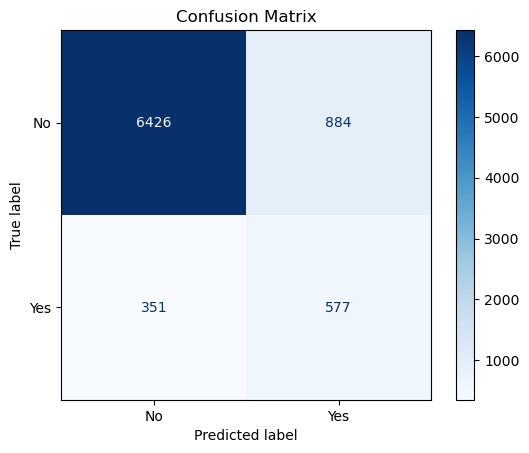

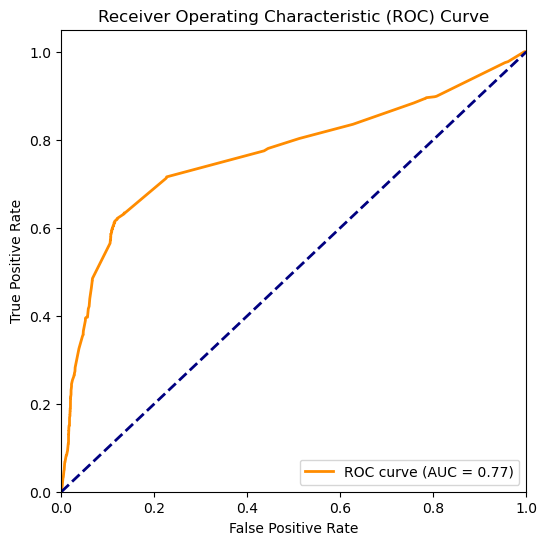

In [488]:
# Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    pipeline_svc,
    X_test,
    y_test,
    display_labels=['No', 'Yes'],
    cmap=plt.cm.Blues,
    normalize=None  # change to 'true' for normalized percentages
)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_prob = pipeline_svc.predict_proba(X_test)[:, 1]  # probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

#Finding - 
# Of 928 actual subscribers (yes):
# 577 correctly caught   (62% recall)
# 351 missed completely  (38% missed) 

# Of 7310 non-subscribers (no):
# 6426 correctly rejected (88%)
# 884 wrongly flagged (12%)


# Business Impact - 
# Out of all calls made 12% of the calls were wrongly flagged as interested in taking on the membership. Hence wating time and effort,
# However 62% of the calls made were correctly identified as subscribers
# 38% of actual subscribers were missed.

In [489]:
#Improving model by improving the threshold

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold that maximizes F1
f1_scores     = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx      = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Precision at best threshold: {precisions[best_idx]:.2f}")
print(f"Recall at best threshold:    {recalls[best_idx]:.2f}")
print(f"F1 at best threshold:        {f1_scores[best_idx]:.2f}")

#Finding - it seems like by adjusting the threshold, precision can be increased to 41% from 39% 

Best threshold: 0.78
Precision at best threshold: 0.41
Recall at best threshold:    0.61
F1 at best threshold:        0.49


In [490]:
# Decision tree pipeline
pipeline_dtc = ImbPipeline(steps=[
        ('preprocessor', transformer_log),
        ('feature_selection', SelectKBest(mutual_info_classif, k=5)),
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(max_depth=7,criterion='entropy'))
    ])

pipeline_dtc.fit(X_train,y_train)

y_pred_d = pipeline_dtc.predict(X_test)

print(classification_report(y_test, y_pred_d))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.64      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238



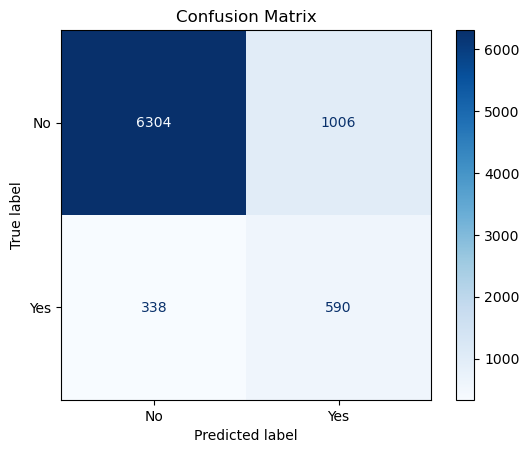

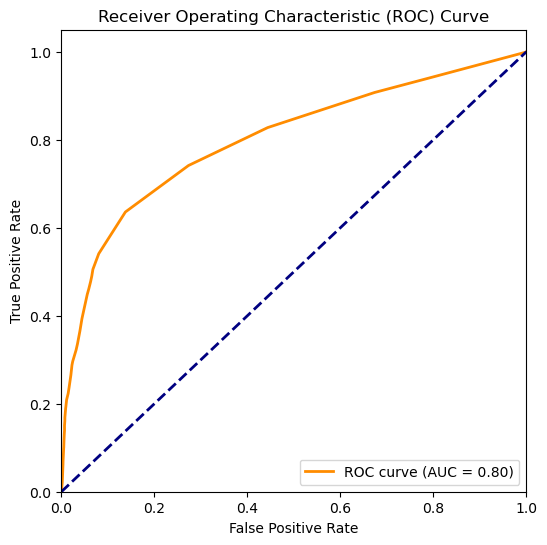

In [491]:
# Confusion Matrix

disp = ConfusionMatrixDisplay.from_estimator(
    pipeline_dtc,
    X_test,
    y_test,
    display_labels=['No', 'Yes'],
    cmap=plt.cm.Blues,
    normalize=None  # change to 'true' for normalized percentages
)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_prob_d = pipeline_dtc.predict_proba(X_test)[:, 1]  # probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob_d)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [492]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_d)

# Find threshold that maximizes F1
f1_scores     = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx      = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Precision at best threshold: {precisions[best_idx]:.2f}")
print(f"Recall at best threshold:    {recalls[best_idx]:.2f}")
print(f"F1 at best threshold:        {f1_scores[best_idx]:.2f}")

Best threshold: 0.77
Precision at best threshold: 0.46
Recall at best threshold:    0.54
F1 at best threshold:        0.50


In [ ]:
# SVC seems to be the best model for this Classification.

##### Questions